Nuestro proyecto consiste en el uso de una red neuronal convolucional, específicamente MobileNetV2, para clasificar radiografías de tórax en dos categorías: Normal y Neumonía.
El objetivo principal fue explorar cómo un modelo de visión artificial puede apoyar el diagnóstico médico, analizando su rendimiento y las limitaciones que presenta.

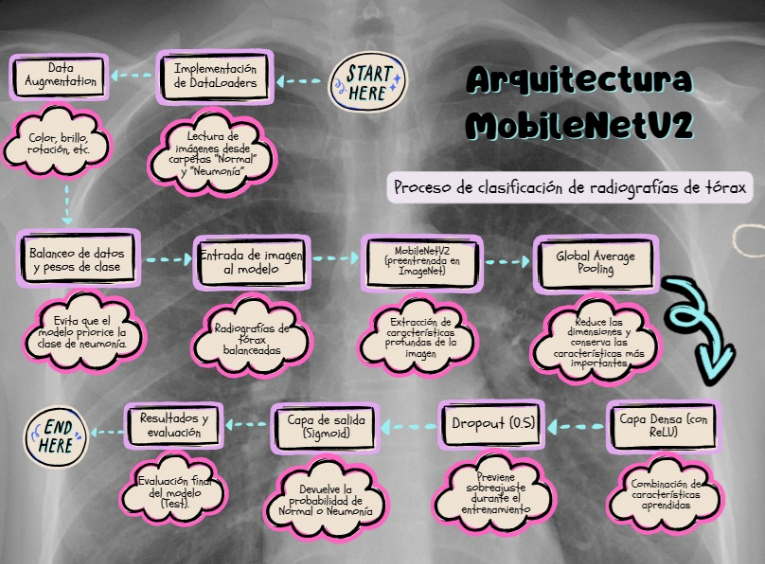


In [ ]:
from collections import Counter
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torch.utils.data import WeightedRandomSampler
import numpy as np
import torch
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D,Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight

In [ ]:
# Ruta al dataset 
data_dir = r"C:/Users/joveninvestigador/Desktop/Valentina Lopera/archive/chest_xray"

#Se cargan tres conjuntos de imágenes: entrenamiento, validación y prueba
#ImageFolder detecta automáticamente las clases (Normal-Neumonía)
train_dataset = datasets.ImageFolder(root=data_dir + r"/train")
val_dataset   = datasets.ImageFolder(root=data_dir + r"/val")
test_dataset  = datasets.ImageFolder(root=data_dir + r"/test")

# Ver clases detectadas automáticamente y el número de imágenes que hay en cada conjunto.
print("Clases:", train_dataset.classes)
print("Tamaño train:", len(train_dataset))
print("Tamaño val:", len(val_dataset))
print("Tamaño test:", len(test_dataset))


print("\nNORMAL=0, PNEUMONIA=1")
#Cuenta cuántas imágenes hay de cada clase en el conjunto de entrenamiento, prueba y validacion 
# Contar en train
conteo_train = Counter(train_dataset.targets)
print("Train:", conteo_train)

# Contar en val
conteo_val = Counter(val_dataset.targets)
print("Val:", conteo_val)

# Contar en test
conteo_test = Counter(test_dataset.targets)
print("Test:", conteo_test)

Clases: ['NORMAL', 'PNEUMONIA']
Tamaño train: 5216
Tamaño val: 16
Tamaño test: 624

NORMAL=0, PNEUMONIA=1
Train: Counter({1: 3875, 0: 1341})
Val: Counter({0: 8, 1: 8})
Test: Counter({1: 390, 0: 234})


In [ ]:
# Transformaciones

# Augmentación fuerte SOLO para NORMAL, para que el modelo vea muchas versiones distintas de una misma imagen, aprenda mejor y evita sobreajuste.
normal_transform = transforms.Compose([
    transforms.Resize((180,180)), # Redimensiona la imagen a 180x180 píxeles (hace que todas tengan igual tamaño(fijo) y asi la RN pueda procesar).
    transforms.RandomHorizontalFlip(p=0.5), # Con probabilidad 0.5 voltea horizontalmente (como si fuera un espejo).
    transforms.RandomRotation(15), # Rota la imagen de forma aleatoria entre -15° y +15°. (para aumentar datos y que aprenda mas).
    transforms.ColorJitter(brightness=0.3, contrast=0.3), # Cambia brillo/contraste de forma aleatoria (augmentation).
    transforms.ToTensor(), # Convierte la imagen PIL a tensor PyTorch y normaliza los valores a [0,1], ya que la RN a red neuronal solo puede trabajar con tensores numéricos.
    transforms.Normalize((0.5,), (0.5,))  #Ajusta los valores de los píxeles para que estén entre -1 y 1 (Las centra)
])
# Transformación simple para PNEUMONIA, ya que el dataset ya tiene suficientes imágenes de esa clase y/o menos distorciones de rediografias enfermas
pneumonia_transform = transforms.Compose([
    transforms.Resize((180,180)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Para validación y test (sin augmentación),porque se necesita evaluar el modelo con imágenes “reales”, sin cambios.
val_test_transform = transforms.Compose([
    transforms.Resize((180,180)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Solo define cómo leer las imágenes cuando se soliciten.
train_dataset_normal = datasets.ImageFolder(root=data_dir + r"/train", transform=normal_transform)  
train_dataset_pneu   = datasets.ImageFolder(root=data_dir + r"/train", transform=pneumonia_transform) #normal_transform describe cómo se deben leer 

# Se recorren todas las imágenes del dataset de entrenamiento y busca las posiciones de cada clase para separarlas. 
normal_indices    = [i for i, (_, label) in enumerate(train_dataset_normal.samples) if label == 0]
pneumonia_indices = [i for i, (_, label) in enumerate(train_dataset_pneu.samples) if label == 1]

# Aquí se crean dos carpetas VIRTUALES: uno que contiene solo las imágenes normales y otro solo las de neumonía.
normal_dataset    = Subset(train_dataset_normal, normal_indices)
pneumonia_dataset = Subset(train_dataset_pneu, pneumonia_indices)

# Combinar datasets balanceados, para tener un solo dataset de entrenamiento
train_dataset = ConcatDataset([normal_dataset, pneumonia_dataset])

#  Cargar val y test
val_dataset  = datasets.ImageFolder(root=data_dir + r"/val", transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=data_dir + r"/test", transform=val_test_transform)

# Verificar tamaños
print("Train size total:", len(train_dataset))
print("   NORMAL:", len(normal_dataset))
print("   PNEUMONIA:", len(pneumonia_dataset))
print("Val size:", len(val_dataset))

Train size total: 5216
   NORMAL: 1341
   PNEUMONIA: 3875
Val size: 16


In [ ]:

# ALTERNATIVAS QUE APLICAMOS PARA EL BALANCEO DE DATOS

#1
targets = []
for ds in train_dataset.datasets:  # Este ciclo for recorre normal_dataset y pneumonia_dataset
    if hasattr(ds, "dataset"):     #Saca todas las etiquetas (labels) de cada imagen y las guarda en una lista llamada targets.
        targets.extend([ds.dataset.samples[i][1] for i in ds.indices])
    else:
        targets.extend([s[1] for s in ds.samples])

# Contar cuántas imágenes hay por clase, por ejemplo [200, 800]
class_counts = np.bincount(targets)

# Calcular el peso inverso a la frecuencia (clases minoritarias tendrán mayor peso)
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float) #Esto toma el inverso de esos números, o sea: 1/200, 1/800 , [0.005, 0.00125]
#Así el modelo “entiende” que debe prestar más atención a la clase minoritaria.

factor = 2.0  # duplica el peso de la clase minoritaria
class_weights[0] *= factor  #  la clase 0 es la minoritaria

# Revisa cada imagen del dataset, mira qué clase tiene (label), y asígna el peso correspondiente según class_weights”.
sample_weights = [class_weights[label] for label in targets] 

# Sirve para que el modelo vea más veces las imágenes de la clase que tiene menos cantidad, normal (Hace que cojas mas de normal y se equilibre el train)
sampler = WeightedRandomSampler(    
    weights=sample_weights, #Cada imagen tiene un peso y las imágenes minoritarias (de clase 0) tienen más peso → se eligen más veces.
    num_samples=len(sample_weights),  # se van a usar la misma cantidad de muestras que hay en el dataset completo.
    replacement=True                  # Permite que una misma imagen pueda repetirse varias veces si tiene mucho peso y el modelo aprenda bien de cada imagen
)

# =============================
# 4. Crear los DataLoaders ------entrega las imágenes balanceadas y por lotes al modelo.
# =============================

train_loader = DataLoader(
    train_dataset, #conjunto de imágenes ya transformadas y balanceadas.
    batch_size=32, #Significa que el modelo verá 32 imágenes por paso de entrenamiento.
    sampler=sampler,    #hace que salgan más imágenes de la clase minoritaria (NORMAL) -- reemplaza shuffle=True
    num_workers=2   #le dice a PyTorch que use 2 procesos en paralelo para cargar las imágenes más rápido.
)

val_loader = DataLoader(    #no se usa sampler ni shuffle, porque en validación
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(    #no se usa sampler ni shuffle, porque en validación
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# Verificación
print("Imágenes por clase en train:", class_counts.tolist())
print("Pesos asignados:", class_weights.tolist())
#Esto solo muestra cuántas imágenes hay de cada clase y los pesos que se aplicaron, para verificar que efectivamente el dataset quedó balanceado.

Imágenes por clase en train: [1341, 3875]
Pesos asignados: [0.0014914242783561349, 0.000258064508670941]


INTENTO ARQUITECTURA DIFERENTE


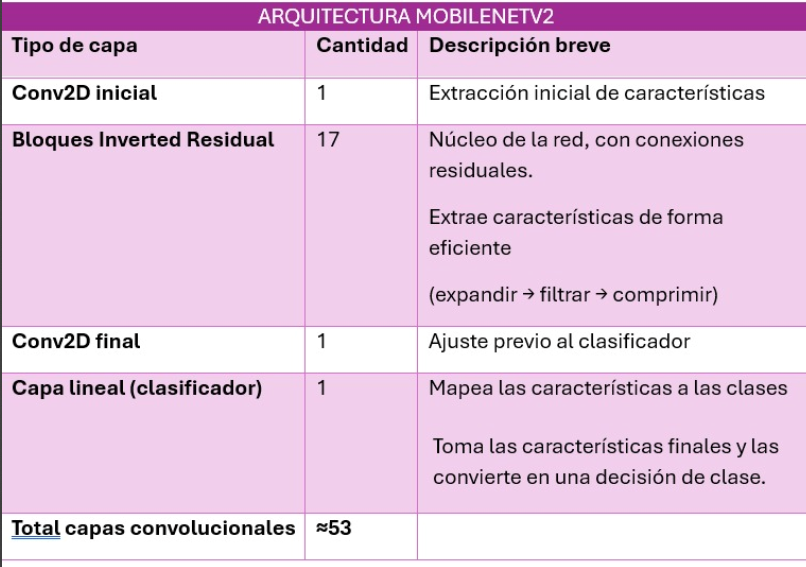

In [ ]:
def extract_numpy(dataloader):   
    X_list, Y_list = [], []   #Se crean dos listas vacías: X_list: para guardar todas las imágenes. Y_list: para guardar todas las etiquetas (0 = Normal, 1 = Neumonía).
    for X, Y in dataloader: #Recorre todo el DataLoader (por ejemplo, train_loader o val_loader).
        # CORRECTO: (N, C, H, W) → (N, H, W, C)
        X = X.permute(0, 2, 3, 1)  #Esto reordena las dimensiones de las imágenes.
        X_list.append(X) #Guarda cada batch (grupo de imágenes y etiquetas) dentro de las listas.
        Y_list.append(Y)   #guarda etiquetas

    #Une todas las partes (batches) en un solo bloque:
    X_all = torch.cat(X_list, dim=0)
    Y_all = torch.cat(Y_list, dim=0)

    # Convierte los tensores de PyTorch a arreglos NumPy, con formato de números decimales (float32),
    X_all = X_all.numpy().astype("float32")
    Y_all = Y_all.numpy().astype("float32")

    # Normalizar
    if X_all.max() > 1.0:
        X_all /= 255.0

    return X_all, Y_all     #Devuelve todas las imágenes y etiquetas (0 o 1)  en NumPy.

X_train, Y_train = extract_numpy(train_loader)     #las extrae de las que ya esyaban para convertirlas
X_val, Y_val = extract_numpy(val_loader)
X_test, Y_test = extract_numpy(test_loader)

print("✅ Formato final:")
print(X_train.shape)  # debe ser (N, 180, 180, 3)


In [ ]:

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(180,180,3))   #imagenet son ajustes que tu modelo ya sabe reconocer cosas básicas en imágenes,
#ultima capa de clasificacion inactiva debido a que solo se va a clasificar en 2 categorias no 1000
for layer in base.layers:   #Recorre todas las capas del modelo MobileNetV2 (base.layers)
    layer.trainable = False  # congela las capas base, no pierde sus datos internos y de acuerdos a ellos ya sabe

x = base.output    #información que él detectó de la imagen.
x = GlobalAveragePooling2D()(x)    #reduce la información sin perder lo importante, para poder conectarla con capas densas.
x = Dense(128, activation='relu')(x) #se crean reglas nuevas basadas en lo que MobileNetV2 ya vio, es como el que diagnostica jeje
x = Dropout(0.5)(x)  #apagamos algunas neuronas al azar. Esto obliga al modelo a no depender de una sola regla y aprender de forma más general.
output = Dense(1, activation='sigmoid')(x)  #toma la desicion final 
#1 significa que solo va a dar una salida, porque tú quieres decidir entre dos
#activation='sigmoid' es probabilidad

#entrenamiento del modelo 
model = Model(inputs=base.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\joveninvestigador\AppData\Local\Temp\ipykernel_18340\3877611302.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(180,180,3))


In [ ]:
#reduce automáticamente la tasa de aprendizaje si el modelo deja de mejorar.
#detiene el entrenamiento si el modelo ya no mejora en los datos de validación.
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]
#EVITA EL SOBRENTRENAMIENTO 

In [ ]:
history = model.fit(       #FUNCION QUE ENTRENA MI MODELO 
    X_train, y_train,          
    validation_data=(X_val, y_val),   #Mientras el modelo se entrena, revisa qué tan bien lo hace en datos que no ha visto
    epochs=30,   #Entrena el modelo 30 veces sobre todo el conjunto de entrenamiento.
    batch_size=32,     #Divide tus datos en grupos de 32 imágenes.
    callbacks=callbacks,
    verbose=1     #1 → barra de progreso y métricas por época.
) 


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 317ms/step - accuracy: 0.4998 - loss: 0.7343 - val_accuracy: 0.5000 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 251ms/step - accuracy: 0.5234 - loss: 0.6924 - val_accuracy: 0.7500 - val_loss: 0.6890 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 260ms/step - accuracy: 0.5556 - loss: 0.6847 - val_accuracy: 0.5000 - val_loss: 0.6877 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 267ms/step - accuracy: 0.5782 - loss: 0.6816 - val_accuracy: 0.5000 - val_loss: 0.6869 - learning_rate: 1.0000e-04
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 269ms/step - accuracy: 0.5736 - loss: 0.6794 - val_accuracy: 0.5625 - val_loss: 0.6838 - learning_rate: 1.0000e-04
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 277ms/step - accuracy: 0.6012 - loss: 0.6745 - val_accuracy: 0.6875 - val_loss: 0.6822 - learning_rate: 1.0000e-04
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 26

In [ ]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f"🔹 Pérdida en test: {test_loss:.4f}")
print(f"🔹 Exactitud en test: {test_acc:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 248ms/step - accuracy: 0.7356 - loss: 0.6231
🔹 Pérdida en test: 0.6231
🔹 Exactitud en test: 0.7356


Después de 30 épocas de entrenamiento, el modelo alcanzó una exactitud del 73.6% y una pérdida de 0.62 en el conjunto de prueba.
Esto indica que el modelo logra clasificar correctamente alrededor de 3 de cada 4 radiografías.”

Si bien el resultado no es perfecto, es un desempeño aceptable considerando que el modelo base fue congelado y que el dataset médico tiene alta variabilidad y dificultad. Los resultados muestran que el modelo logró aprender patrones visuales asociados a la neumonía.”

La precisión se ve limitada por factores como el tamaño del dataset, el desbalance entre clases y el hecho de que no se reajustaron (fine-tuned) las capas profundas del modelo. Aun así, la red logró generalizar de forma razonable.”

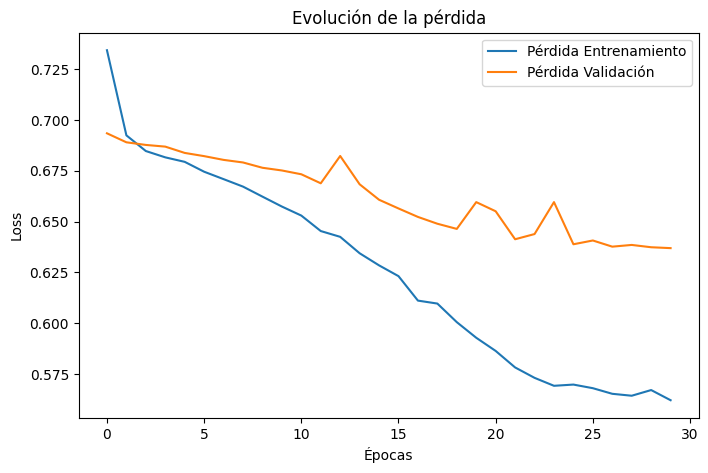

In [ ]:
import matplotlib.pyplot as plt

# --- Pérdida (Loss) ---
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 303ms/step

📊 Reporte - Entrenamiento
              precision    recall  f1-score   support

           0       0.86      0.79      0.83      2672
           1       0.80      0.87      0.83      2544

    accuracy                           0.83      5216
   macro avg       0.83      0.83      0.83      5216
weighted avg       0.83      0.83      0.83      5216



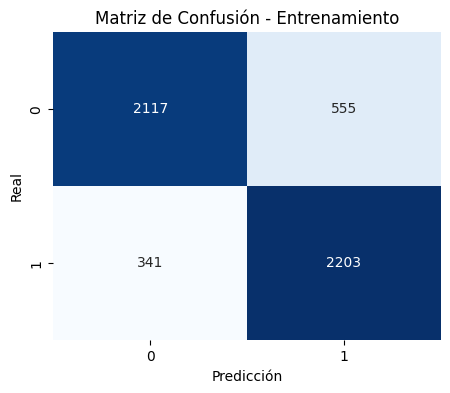

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 336ms/step

📊 Reporte - Prueba
              precision    recall  f1-score   support

           0       0.68      0.55      0.61       234
           1       0.76      0.85      0.80       390

    accuracy                           0.74       624
   macro avg       0.72      0.70      0.70       624
weighted avg       0.73      0.74      0.73       624



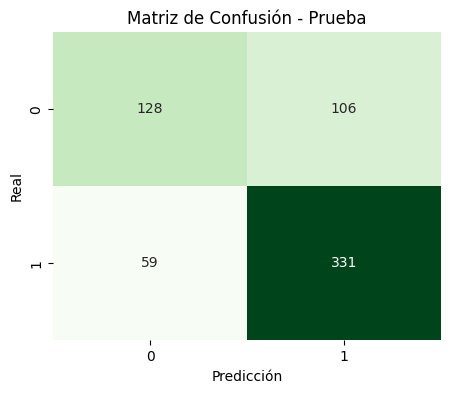

In [ ]:
# ==============================
# Matriz de confusión y reporte
# ==============================
# Predicciones entrenamiento
y_train_pred = (model.predict(X_train) > 0.5).astype("int32")
print("\n📊 Reporte - Entrenamiento")
print(classification_report(Y_train, y_train_pred))      #classification_report de sklearn muestra las metricas

cm_train = confusion_matrix(Y_train, y_train_pred)      
plt.figure(figsize=(5,4))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de Confusión - Entrenamiento")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# Predicciones prueba
y_test_pred = (model.predict(X_test) > 0.5).astype("int32")
print("\n📊 Reporte - Prueba")
print(classification_report(Y_test, y_test_pred))

cm_test = confusion_matrix(Y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Matriz de Confusión - Prueba")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step

📊 Reporte - validación
              precision    recall  f1-score   support

           0       1.00      0.38      0.55         8
           1       0.62      1.00      0.76         8

    accuracy                           0.69        16
   macro avg       0.81      0.69      0.65        16
weighted avg       0.81      0.69      0.65        16



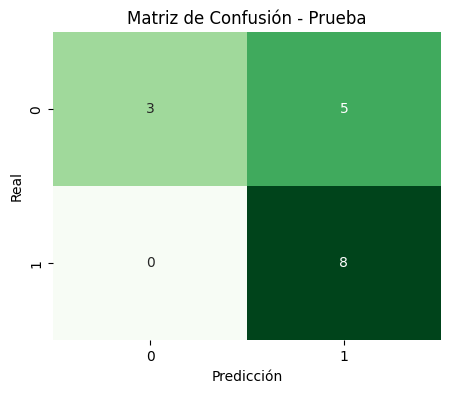

In [ ]:
# Predicciones prueba
y_val_pred = (model.predict(X_val) > 0.5).astype("int32")
print("\n📊 Reporte - validación")
print(classification_report(Y_val, y_val_pred))

cm_val = confusion_matrix(Y_val, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Matriz de Confusión - Val ")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()